In [164]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.optimize import minimize

# 1. Поиск критической точки


def characteristic_polynomial(z: float) -> float:
    # Характеристический полином для кубической регрессии
    return 3*z**5 - 11*z**4 + 30*z**3 - 60*z**2 + 32*z - 64


def find_z_star(tolerance: float = 1e-12) -> float:
    # Нахождение квадрата критического радиуса методом Ньютона
    def df(z):
        # Аналитическая производная полинома для метода Ньютона
        return 15*z**4 - 44*z**3 + 90*z**2 - 120*z + 32

    result = root_scalar(characteristic_polynomial, fprime=df,
                         x0=2.6, method='newton', xtol=tolerance)
    if result.converged:
        return result.root
    else:
        raise RuntimeError(
            "Численный метод нахождения критической точки не сошелся")


# 2. Определение геометрических параметров интервала
def calculate_geometry(r1: float, r2: float):
    # Расчет радиуса r, центра омега и проверка критичности отрезка
    if r1 >= r2:
        raise ValueError(f"Левая граница должна быть строго меньше правой!")

    r = (r2 - r1) / 2.0
    omega = (r1 + r2) / 2.0
    z = r**2

    poly_val = characteristic_polynomial(z)

    # Учитываем погрешность вычислений при проверке знака полинома
    if abs(poly_val) < 1e-13:
        is_critical = False
    else:
        is_critical = poly_val > 0

    return r, omega, is_critical


# 3. Алгебра степенных рядов
def series_add(A, B):
    # Сложение коэффициентов рядов
    return A + B


def series_sub(A, B):
    # Вычитание коэффициентов рядов
    return A - B


def series_mul(A, B, order=10):
    # Умножение рядов через свертку коэффициентов
    C = np.zeros(order + 1)
    for n in range(order + 1):
        C[n] = sum(A[i] * B[n - i] for i in range(n + 1))
    return C


def series_div(A, B, order=10):
    # Деление рядов методом неопределенных коэффициентов
    C = np.zeros(order + 1)
    C[0] = A[0] / B[0]
    for n in range(1, order + 1):
        C[n] = (A[n] - sum(C[i] * B[n - i] for i in range(n))) / B[0]
    return C


# 4. Построение плана для докритического симметричного отрезка
def solve_symmetric_subcritical(r: float):
    # Оптимальный план Чебышёва при r <= r*
    points = np.array([-r, -r/2.0, r/2.0, r])

    r4 = r**4
    mu = (12 * r4 + 16) / (3 * (9 * r4 + 16))
    weights = np.array([0.5 - mu, mu, mu, 0.5 - mu])
    lambda_star = (r**6) / (9 * r4 + 16)

    return points, weights, lambda_star


# 5. Рекурсивное вычисление коэффициентов разложения
def compute_base_coefficients(order: int = 15):
    # Нахождение коэффициентов разложения для симметричного отрезка
    a = np.zeros(order + 1)
    b = np.zeros(order + 1)
    d = np.zeros(order + 1)
    lam = np.zeros(order + 1)

    # Начальные условия при бесконечном радиусе отрезка
    a[0], b[0], d[0], lam[0] = 0.0, 0.5, 1.0, 1.0

    b2 = np.zeros(order + 1)
    d2 = np.zeros(order + 1)
    db = np.zeros(order + 1)

    b2[0] = b[0] * b[0]
    d2[0] = d[0] * d[0]
    db[0] = d[0] * b[0]

    def val(arr, idx):
        return arr[idx] if 0 <= idx < len(arr) else 0.0

    # Нахождение коэффициентов на шаге n
    for n in range(1, order + 1):
        # 1. Вычисление b_n
        sum_b1 = sum(d[i]*d[n-i] - a[i]*a[n-i] for i in range(1, n))
        sum_b2 = sum(b[i]*(a[n-i] - d[n-i]) for i in range(1, n))
        b[n] = 0.5 * sum_b1 + 2.0 * sum_b2

        # 2. Вычисление d_n
        psi = 1.0 if n == 3 else (-1.0 if n == 4 else 0.0)

        term1 = sum(d2[i] * (val(b2, n-1-i) - 2*val(b, n-1-i))
                    for i in range(n))
        term2 = -val(d2, n-2)
        term3 = sum(val(b2, n-i) * (d[i] - d2[i]) for i in range(1, n))
        term4 = sum(d2[i] * val(b, n-2-i) for i in range(n-1))
        term5 = (val(d, n-2) - 2*val(d, n-3) + val(b2, n-2) + val(b, n-4) +
                 val(db, n-1) - 2*val(db, n-2) + val(db, n-3) + psi)

        sum_d1 = sum(d[i]*d[n-i] for i in range(1, n))
        d[n] = 4.0 * (term1 + term2 + term3 + term4 + term5) - sum_d1

        # 3. Вычисление a_n
        sum_a1 = sum(val(db, n-i)*(d[i] - a[i]) + a[i] *
                     (val(d, n-i) - val(d, n-1-i)) for i in range(1, n))
        a[n] = -d[n] + 2.0 * (val(d, n-1) - val(a, n-1) +
                              val(b, n-2) - val(d, n-2) - val(d2, n-1) - sum_a1)

        # 4. Вычисление lambda_n
        sum_l1 = sum(lam[i] * (val(d, n-1-i) + val(db, n-i) -
                     val(b2, n-i)) for i in range(1, n))
        lam[n] = -4.0 * (val(lam, n-2) + val(d, n-1) + sum_l1)

        # Обновление сверток для последующих шагов рекурсии
        b2[n] = sum(b[i]*b[n-i] for i in range(n + 1))
        d2[n] = sum(d[i]*d[n-i] for i in range(n + 1))
        db[n] = sum(d[i]*b[n-i] for i in range(n + 1))

    return a, b, d, lam, b2, d2, db


# 6. Построение плана для критического симметричного отрезка
def solve_symmetric_critical(r: float, order: int = 15):
    # Вычисление точек и весов по рядам Тейлора при r > r*
    z = r**2
    a, b, d, lam, _, _, _ = compute_base_coefficients(order)

    inv_z = 1.0 / z
    inv_z_pow = 1.0
    a_val, b_val, d_val, lam_val = 0.0, 0.0, 0.0, 0.0

    for n in range(order + 1):
        a_val += a[n] * inv_z_pow
        b_val += b[n] * inv_z_pow
        d_val += d[n] * inv_z_pow
        lam_val += lam[n] * inv_z_pow
        inv_z_pow *= inv_z

    t_a = a_val * z
    t_b = b_val * z
    t_d = d_val * z

    num = (1.0 + t_d) * (t_b - z) - z * t_b * (t_d - t_b)
    den = (t_a - z) * (1.0 + t_d + t_b * (t_d - t_b))
    mu_val = num / den

    x_tilde = np.sqrt(t_a)

    points = np.array([-r, -x_tilde, x_tilde, r])
    weights = np.array([(1.0 - mu_val) / 2.0, mu_val / 2.0,
                       mu_val / 2.0, (1.0 - mu_val) / 2.0])

    return points, weights, lam_val


# 7. Генерация и вывод таблицы коэффициентов
def generate_coefficients_table(order: int = 10):
    # Построение рядов для таблицы, включая деление рядов для mu
    a, b, d, lam, b2, d2, db = compute_base_coefficients(order)

    x = np.zeros(order + 1)
    x[1] = 1.0
    x2 = np.zeros(order + 1)
    x2[2] = 1.0

    b_minus_1 = b.copy()
    b_minus_1[0] -= 1.0
    a_minus_1 = a.copy()
    a_minus_1[0] -= 1.0

    db_minus_b2 = series_sub(db, b2)

    term1 = series_mul(x2, b_minus_1, order)
    term2 = series_mul(x, series_mul(d, b_minus_1, order), order)
    Num = series_sub(series_add(term1, term2), db_minus_b2)

    term3 = series_add(x2, series_mul(x, d, order))
    term4 = series_add(term3, db_minus_b2)
    Den = series_mul(a_minus_1, term4, order)

    mu = series_div(Num, Den, order)

    return a, b, d, mu, lam


def print_coefficients_table(order: int = 10):
    # Форматированный консольный вывод рассчитанной таблицы коэффициентов
    a, b, d, mu, lam = generate_coefficients_table(order)

    def fmt(val):
        if np.isclose(val, round(val), atol=1e-9):
            return str(int(round(val)))
        return f"{val:g}"

    rows = {'a': a, 'b': b, 'd': d, 'μ': mu, 'λ': lam}
    col_widths = [6] + [8] * (order + 1)

    header_top = "┌" + "┬".join("─" * w for w in col_widths) + "┐"
    header_mid = "├" + "┼".join("─" * w for w in col_widths) + "┤"
    header_bot = "└" + "┴".join("─" * w for w in col_widths) + "┘"

    print("\n" + " " * 15 +
          f"Table of expansion coefficients (Order {order})")
    print(header_top)
    print(f"│ {'N':^4} │ " + " │ ".join(f"{fmt(i)          :^6}" for i in range(order + 1)) + " │")
    print(header_mid)
    for name, values in rows.items():
        row_cells = [f"{fmt(v):^6}" for v in values]
        print(f"│ {name:^4} │ " + " │ ".join(row_cells) + " │")
    print(header_bot)


# 8. Численный оптимизатор для произвольного отрезка
def solve_numerical_arbitrary(r1: float, r2: float):
    # Поиск плана на произвольном отрезке методом последовательного квадратичного программирования
    r, omega, is_critical = calculate_geometry(r1, r2)

    # Сдвиг симметричного плана для построения начального приближения
    if is_critical:
        p_sym, w_sym, _ = solve_symmetric_critical(r)
    else:
        p_sym, w_sym, _ = solve_symmetric_subcritical(r)

    x1_init = p_sym[1] + omega
    x2_init = p_sym[2] + omega
    w0_init, w1_init, w2_init = w_sym[0], w_sym[1], w_sym[2]

    # Целевая функция (минимизация отрицательного собственного числа)
    def objective(v):
        x1, x2, w0, w1, w2 = v
        w3 = 1.0 - w0 - w1 - w2

        pts = np.array([r1, x1, x2, r2])
        wts = np.array([w0, w1, w2, w3])

        M = build_information_matrix(pts, wts)
        return -get_min_eigenvalue(M)

    # Ограничения на неотрицательность весов и упорядоченность точек
    def constraint_weights(v):
        return 1.0 - (v[2] + v[3] + v[4])

    def constraint_order(v):
        return v[1] - v[0]

    bounds = [(r1, r2), (r1, r2), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

    constraints = [
        {'type': 'ineq', 'fun': constraint_weights},
        {'type': 'ineq', 'fun': constraint_order}
    ]

    v0 = [x1_init, x2_init, w0_init, w1_init, w2_init]

    res = minimize(objective, v0, bounds=bounds,
                   constraints=constraints, method='SLSQP', tol=1e-10)

    if not res.success:
        print("Warning: optimizer did not converge successfully")

    x1_opt, x2_opt, w0_opt, w1_opt, w2_opt = res.x
    w3_opt = 1.0 - w0_opt - w1_opt - w2_opt

    points = np.array([r1, x1_opt, x2_opt, r2])
    weights = np.array([w0_opt, w1_opt, w2_opt, w3_opt])
    lam_star = -res.fun

    return points, weights, lam_star


# 9. Расчет стартового вектора в точке симметрии
# =====================================================================
# ВСПОМОГАТЕЛЬНЫЙ АЛГОРИТМ: ПОЛУЧЕНИЕ СТАРТОВОГО ВЕКТОРА ТЕТА_0
# =====================================================================

def get_symmetric_theta_0_vector(r: float):
    """
    Вычисляет точный 11-мерный вектор начальных условий theta_0 при omega=0,
    используя строгое нормирование следа двойственной матрицы (Cp^2 + Cq^2 = 1).
    """
    pts, wts, lam_star = solve_symmetric_critical(r)
    
    x2_norm = pts[1] / r
    x3_norm = pts[2] / r
    
    # Строим реальную матрицу Фишера 4x4
    M_real = np.zeros((4, 4))
    for i in range(4):
        f = np.array([1, pts[i], pts[i]**2, pts[i]**3])
        M_real += wts[i] * np.outer(f, f)
        
    M13 = M_real[np.ix_([0, 2], [0, 2])]
    M24 = M_real[np.ix_([1, 3], [1, 3])]
    
    vals1, evecs1 = np.linalg.eigh(M13)
    u_even = evecs1[:, np.argmin(vals1)] # u = [u0, u2]
    
    vals2, evecs2 = np.linalg.eigh(M24)
    v_odd = evecs2[:, np.argmin(vals2)]  # v = [v1, v3]
    
    # Обозначим U = u(r), V = q(r). Из условий двойственности:
    # Cp^2 * U^2 + Cq^2 * V^2 = lam_star  и  Cp^2 + Cq^2 = 1
    U = u_even[0] + u_even[1] * r**2
    V = v_odd[0] * r + v_odd[1] * r**3
    
    # Находим точные веса Cp и Cq без нарушения масштаба
    Cp2 = (lam_star - V**2) / (U**2 - V**2)
    Cp = np.sqrt(max(0.0, min(1.0, Cp2)))
    Cq = np.sqrt(1.0 - Cp**2)
    
    p0_val = Cp * u_even[0]
    p1_val = 0.0
    p2_val = Cp * u_even[1]
    
    q0_val = 0.0
    q1_val = Cq * v_odd[0]
    q3_val = Cq * v_odd[1] # Теперь q3 свободный параметр, а не 1.0!
    
    theta_0 = [
        p0_val, p1_val, p2_val,
        q0_val, q1_val, q3_val,
        wts[1], wts[2], wts[3],
        x2_norm, x3_norm
    ]
    return theta_0


# =====================================================================
# АНАЛИТИЧЕСКИЙ МЕТОД СДВИГА ЧЕРЕЗ SYMPY (ФОРМУЛА 8.2)
# =====================================================================

def solve_shifted_design_analytical(r_val: float, omega_val: float, order: int = 1):
    """
    Аналитически вычисляет Е-оптимальный план на произвольном отрезке.
    """
    theta_0_numeric = get_symmetric_theta_0_vector(r_val)

    omega = sp.Symbol('omega', real=True)
    p0, p1, p2 = sp.symbols('p0 p1 p2', real=True)
    q0, q1, q3 = sp.symbols('q0 q1 q3', real=True) # q3 вместо q2!
    mu2, mu3, mu4 = sp.symbols('mu2 mu3 mu4', real=True)
    x2, x3 = sp.symbols('x2 x3', real=True)

    # Вектор переменных: q2 жестко равен 0.0 (в силу нечетности q)
    theta_vars = [p0, p1, p2, q0, q1, q3, mu2, mu3, mu4, x2, x3]

    x1_norm, x4_norm = -1.0, 1.0
    mu1 = 1.0 - mu2 - mu3 - mu4
    p3, q2 = 0.0, 0.0

    X_pts = [
        x1_norm * r_val + omega,
        x2 * r_val + omega,
        x3 * r_val + omega,
        x4_norm * r_val + omega
    ]
    Weights = [mu1, mu2, mu3, mu4]

    x_sym = sp.Symbol('x', real=True)
    p_x = p0 + p1*x_sym + p2*x_sym**2
    q_x = q0 + q1*x_sym + q2*x_sym**2 + q3*x_sym**3

    g_x = p_x**2 + q_x**2
    dg_dx = sp.diff(g_x, x_sym)

    lam = g_x.subs(x_sym, X_pts[3])

    p_coeffs = [p0, p1, p2, p3]
    q_coeffs = [q0, q1, q2, q3]

    # Формируем систему 11 уравнений
    equations = []
    equations.append(g_x.subs(x_sym, X_pts[0]) - lam)
    equations.append(g_x.subs(x_sym, X_pts[1]) - lam)
    equations.append(g_x.subs(x_sym, X_pts[2]) - lam)

    equations.append(dg_dx.subs(x_sym, X_pts[1]))
    equations.append(dg_dx.subs(x_sym, X_pts[2]))

    for k in range(4):
        moment_p = sum(Weights[i] * p_x.subs(x_sym, X_pts[i]) * (X_pts[i]**k) for i in range(4))
        equations.append(moment_p - lam * p_coeffs[k])

    for k in range(2):
        moment_q = sum(Weights[i] * q_x.subs(x_sym, X_pts[i]) * (X_pts[i]**k) for i in range(4))
        equations.append(moment_q - lam * q_coeffs[k])

    F = sp.Matrix(equations)

    G_sym = F.jacobian(theta_vars)
    G_omega_sym = -F.diff(omega)

    subs_list: list[tuple[sp.Basic, float]] = [(omega, 0.0)]
    for i in range(11):
        subs_list.append((theta_vars[i], float(theta_0_numeric[i])))

    G_0_num = np.array(G_sym.subs(subs_list), dtype=np.float64)
    G_0_inv = np.linalg.pinv(G_0_num)

    G_omega_0_num = np.array(G_omega_sym.subs(subs_list), dtype=np.float64).flatten()

    # Редукция Якобиана (индексы: p1 -> 1, q0 -> 3, q3 -> 5)
    active_indices = [1, 3, 5]
    G_reduced = G_0_num[:, active_indices]
    
    theta_active_dot, _, _, _ = np.linalg.lstsq(G_reduced, G_omega_0_num, rcond=None)
    
    theta_1_numeric = np.zeros(11)
    for i, idx in enumerate(active_indices):
        theta_1_numeric[idx] = theta_active_dot[i]

    theta_final = np.array(theta_0_numeric) + theta_1_numeric * omega_val

    mu2_val, mu3_val, mu4_val = theta_final[6], theta_final[7], theta_final[8]
    mu1_val = 1.0 - mu2_val - mu3_val - mu4_val

    x2_norm_val, x3_norm_val = theta_final[9], theta_final[10]

    points = np.array([-r_val, x2_norm_val * r_val, x3_norm_val * r_val, r_val]) + omega_val
    weights = np.array([mu1_val, mu2_val, mu3_val, mu4_val])
    lam_val = float(lam.subs(subs_list))

    return points, weights, lam_val


# 10. Аналитический метод сдвига (Метод Гомотопии / Предиктор-Корректор)
def solve_shifted_design_stepwise(r_val: float, omega_val: float, steps: int = 20):
    """
    Вычисляет Е-оптимальный план на несимметричном отрезке методом продолжения по параметру.
    Шаг 1: Обход точки бифуркации через редукцию.
    Шаг 2..N: Интегрирование вдоль физической ветви со стабилизацией по методу Ньютона.
    """
    theta_0_numeric = get_symmetric_theta_0_vector(r_val)
    
    # 1. Символьные переменные
    omega = sp.Symbol('omega', real=True)
    p0, p1, p2 = sp.symbols('p0 p1 p2', real=True)
    q0, q1, q2 = sp.symbols('q0 q1 q2', real=True)
    mu2, mu3, mu4 = sp.symbols('mu2 mu3 mu4', real=True)
    x2, x3 = sp.symbols('x2 x3', real=True)

    theta_vars = [p0, p1, p2, q0, q1, q2, mu2, mu3, mu4, x2, x3]
    all_vars = theta_vars + [omega] # Порядок для lambdify

    # Жесткие константы
    x1_norm, x4_norm = -1.0, 1.0
    mu1 = 1.0 - mu2 - mu3 - mu4
    p3, q3 = 0.0, 1.0

    X_pts = [
        x1_norm * r_val + omega, x2 * r_val + omega,
        x3 * r_val + omega, x4_norm * r_val + omega
    ]
    Weights = [mu1, mu2, mu3, mu4]

    x_sym = sp.Symbol('x', real=True)
    p_x = p0 + p1*x_sym + p2*x_sym**2
    q_x = q0 + q1*x_sym + q2*x_sym**2 + q3*x_sym**3

    g_x = p_x**2 + q_x**2
    dg_dx = sp.diff(g_x, x_sym)
    lam = g_x.subs(x_sym, X_pts[3])

    p_coeffs = [p0, p1, p2, p3]
    q_coeffs = [q0, q1, q2, q3]

    # 2. Формируем 11 уравнений связи
    equations = []
    equations.append(g_x.subs(x_sym, X_pts[0]) - lam)
    equations.append(g_x.subs(x_sym, X_pts[1]) - lam)
    equations.append(g_x.subs(x_sym, X_pts[2]) - lam)

    equations.append(dg_dx.subs(x_sym, X_pts[1]))
    equations.append(dg_dx.subs(x_sym, X_pts[2]))

    for k in range(4):
        moment_p = sum(Weights[i] * p_x.subs(x_sym, X_pts[i]) * (X_pts[i]**k) for i in range(4))
        equations.append(moment_p - lam * p_coeffs[k])

    for k in range(2):
        moment_q = sum(Weights[i] * q_x.subs(x_sym, X_pts[i]) * (X_pts[i]**k) for i in range(4))
        equations.append(moment_q - lam * q_coeffs[k])

    F_sym = sp.Matrix(equations)
    G_sym = F_sym.jacobian(theta_vars)
    G_omega_sym = -F_sym.diff(omega)

    # 3. КОМПИЛЯЦИЯ В БЫСТРЫЕ ФУНКЦИИ
    eval_F = sp.lambdify(all_vars, F_sym, modules='numpy')
    eval_G = sp.lambdify(all_vars, G_sym, modules='numpy')
    eval_G_omega = sp.lambdify(all_vars, G_omega_sym, modules='numpy')
    eval_lam = sp.lambdify(all_vars, lam, modules='numpy')

    # 4. ШАГОВЫЙ АЛГОРИТМ ГОМОТОПИИ
    theta_curr = np.array(theta_0_numeric, dtype=np.float64)
    d_omega = omega_val / steps

    for step in range(1, steps + 1):
        target_omega = step * d_omega
        prev_omega = target_omega - d_omega
        
        args_prev = (*theta_curr, prev_omega)
        
        # --- ПРЕДИКТОР (Шаг вперед) ---
        if step == 1:
            # На первом шаге (точка бифуркации) используем РЕДУКЦИЮ
            G_0 = np.array(eval_G(*args_prev)).reshape(11, 11)
            G_w_0 = np.array(eval_G_omega(*args_prev)).flatten()
            
            active_indices = [1, 3, 5]
            G_red = G_0[:, active_indices]
            theta_dot_red, _, _, _ = np.linalg.lstsq(G_red, G_w_0, rcond=None)
            
            theta_dot = np.zeros(11)
            for i, idx in enumerate(active_indices):
                theta_dot[idx] = theta_dot_red[i]
        else:
            # Вне бифуркации используем обычный Якобиан
            G_val = np.array(eval_G(*args_prev)).reshape(11, 11)
            G_w_val = np.array(eval_G_omega(*args_prev)).flatten()
            theta_dot = np.dot(np.linalg.pinv(G_val), G_w_val)
            
        # Прогнозируем точку на новом уровне омега
        theta_curr = theta_curr + theta_dot * d_omega
        
        # --- КОРРЕКТОР (Метод Ньютона) ---
        # Притягиваем параметры обратно к идеальному решению (F = 0)
        for _ in range(5):
            args_corr = (*theta_curr, target_omega)
            F_val = np.array(eval_F(*args_corr)).flatten()
            
            # Если мы уже на кривой с огромной точностью - прерываем коррекцию
            if np.linalg.norm(F_val) < 1e-10:
                break
                
            G_val = np.array(eval_G(*args_corr)).reshape(11, 11)
            delta = np.dot(np.linalg.pinv(G_val), -F_val)
            theta_curr += delta

    # 5. ИЗВЛЕЧЕНИЕ ФИНАЛЬНОГО ПЛАНА
    mu2_val, mu3_val, mu4_val = theta_curr[6], theta_curr[7], theta_curr[8]
    mu1_val = 1.0 - mu2_val - mu3_val - mu4_val

    x2_norm_val, x3_norm_val = theta_curr[9], theta_curr[10]

    points = np.array([-r_val, x2_norm_val * r_val, x3_norm_val * r_val, r_val]) + omega_val
    weights = np.array([mu1_val, mu2_val, mu3_val, mu4_val])
    lam_val = float(eval_lam(*theta_curr, omega_val))

    return points, weights, lam_val

# 11. Построение информационной матрицы и расчет собственного числа
def build_information_matrix(points, weights):
    # Построение информационной матрицы Фишера
    M = np.zeros((4, 4))
    for i in range(len(points)):
        f = np.array([1, points[i], points[i]**2, points[i]**3])
        M += weights[i] * np.outer(f, f)
    return M


def get_min_eigenvalue(matrix):
    # Нахождение минимального собственного числа матрицы
    eigenvalues, _ = np.linalg.eigh(matrix)
    return np.min(eigenvalues)


# 12. Диспетчер выбора оптимального метода
def get_optimal_design(r1: float, r2: float, order: int = 15):
    r, omega, is_critical = calculate_geometry(r1, r2)

    if abs(omega) > 1e-10:
        points, weights, l_star = solve_shifted_design_analytical(r, omega)
        return points, weights, l_star

    if is_critical:
        points, weights, l_star = solve_symmetric_critical(r, order=order)
    else:
        points, weights, l_star = solve_symmetric_subcritical(r)

    return points, weights, l_star

In [165]:


# 13. Сравнительные численные эксперименты
r_val = 3.0
omega_val = 0.0001

p_an, w_an, l_an = solve_shifted_design_analytical(r_val, omega_val)

p_num, w_num, l_num = solve_numerical_arbitrary(
    -r_val + omega_val, r_val + omega_val)

print("\n" + "="*60)
print("СРАВНЕНИЕ АНАЛИТИЧЕСКОГО СДВИГА И ЧИСЛЕННОГО РЕШЕНИЯ")
print("="*60)
print(f"Аналитические точки: {np.round(p_an, 5)}")
print(f"Численные точки:     {np.round(p_num, 5)}")
print(f"\nАналитические веса : {np.round(w_an, 5)}")
print(f"Численные веса :     {np.round(w_num, 5)}")

print("\n" + "="*60)
print("ЗНАЧЕНИЯ ДЛЯ ПОДПУНКТА 1.4 (СИММЕТРИЧНЫЕ ПЛАНЫ)")
print("="*60)

# Пример 1: Докритический отрезок r = 1.0
p1, w1, l1 = get_optimal_design(-1.0, 1.0)
print("Пример 1 (r = 1.0):")
print(f"Узлы: {np.round(p1, 4)}")
print(f"Веса: {np.round(w1, 4)}")
print(f"lambda*: {l1:.5f}\n")

# Пример 2: Критический отрезок r = 3.0
p2, w2, l2 = get_optimal_design(-3.0, 3.0, order=15)
print("Пример 2 (r = 3.0):")
print(f"Узлы: {np.round(p2, 4)}")
print(f"Веса: {np.round(w2, 4)}")
print(f"lambda*: {l2:.5f}")







СРАВНЕНИЕ АНАЛИТИЧЕСКОГО СДВИГА И ЧИСЛЕННОГО РЕШЕНИЯ
Аналитические точки: [-2.9999  -0.94332  0.94352  3.0001 ]
Численные точки:     [-2.9999  -0.94397  0.94312  3.0001 ]

Аналитические веса : [0.04394 0.45606 0.45606 0.04394]
Численные веса :     [0.04401 0.45594 0.45598 0.04408]

ЗНАЧЕНИЯ ДЛЯ ПОДПУНКТА 1.4 (СИММЕТРИЧНЫЕ ПЛАНЫ)
Пример 1 (r = 1.0):
Узлы: [-1.  -0.5  0.5  1. ]
Веса: [0.1267 0.3733 0.3733 0.1267]
lambda*: 0.04000

Пример 2 (r = 3.0):
Узлы: [-3.     -0.9434  0.9434  3.    ]
Веса: [0.0439 0.4561 0.4561 0.0439]
lambda*: 0.64311


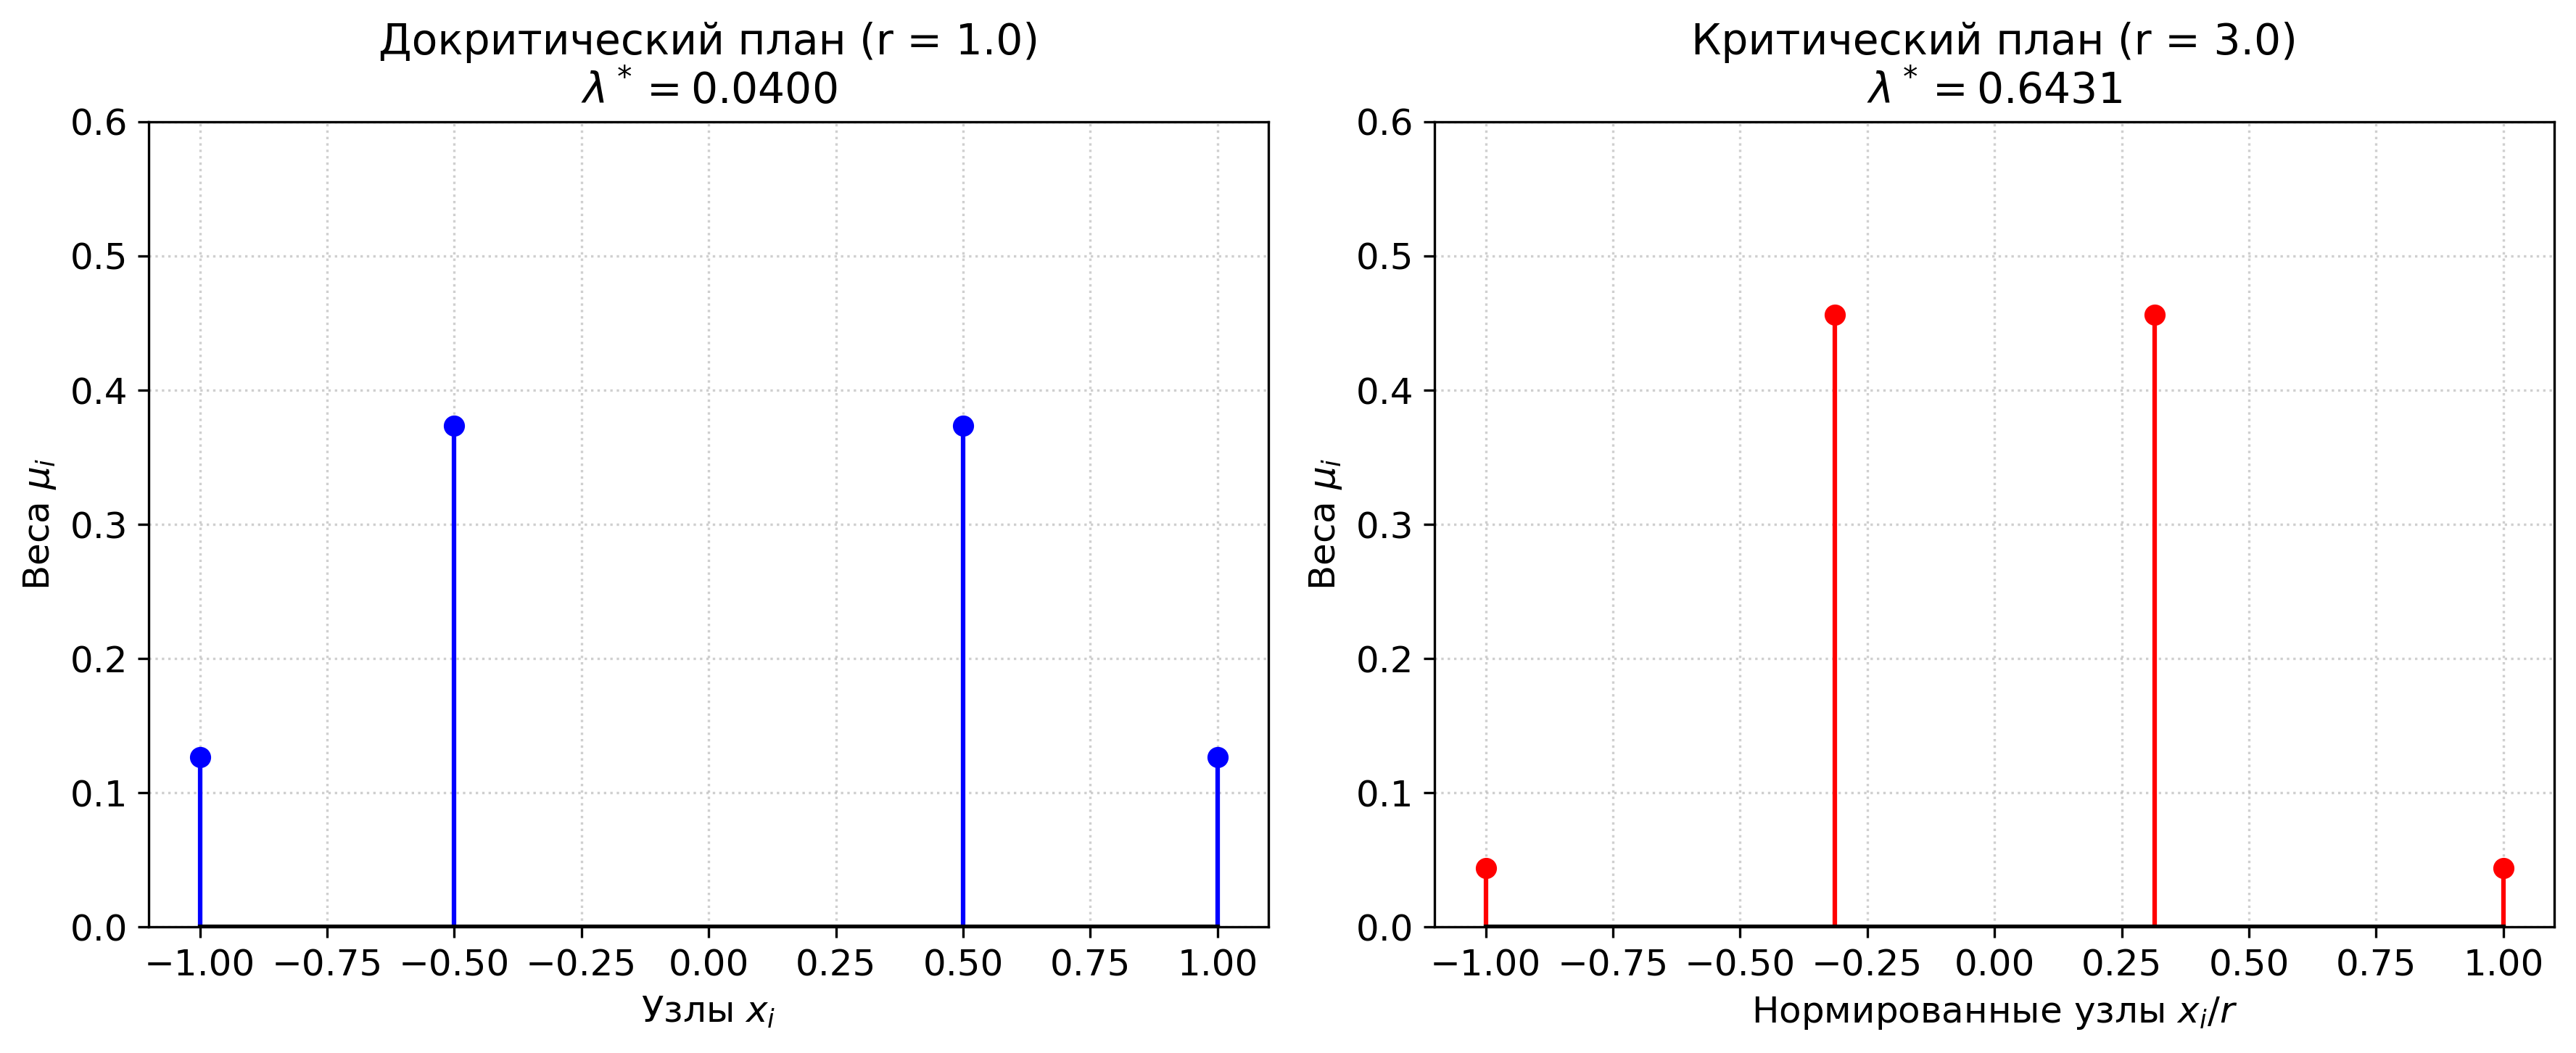

In [166]:
def plot_symmetric_designs():
    """Строит наглядный график расположения точек и их весов."""
    # Получаем планы
    p1, w1, l1 = get_optimal_design(-1.0, 1.0)
    p2, w2, l2 = get_optimal_design(-3.0, 3.0, order=15)

    # Настраиваем стиль графика (как в вашей прошлой работе)
    plt.rcParams.update(
        {'font.size': 12, 'axes.titlesize': 14, 'figure.dpi': 300})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # График 1: r = 1.0
    ax1.stem(p1, w1, linefmt='b-', markerfmt='bo', basefmt='k-')
    ax1.set_title(f'Докритический план (r = 1.0)\n$\lambda^* = {l1:.4f}$')
    ax1.set_xlabel('Узлы $x_i$')
    ax1.set_ylabel('Веса $\mu_i$')
    ax1.set_ylim(0, 0.6)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Нормируем второй план, чтобы графики визуально совпадали по ширине
    # (покажем точки как доли от радиуса)
    p2_norm = p2 / 3.0

    # График 2: r = 3.0
    ax2.stem(p2_norm, w2, linefmt='r-', markerfmt='ro', basefmt='k-')
    ax2.set_title(f'Критический план (r = 3.0)\n$\lambda^* = {l2:.4f}$')
    ax2.set_xlabel('Нормированные узлы $x_i / r$')
    ax2.set_ylabel('Веса $\mu_i$')
    ax2.set_ylim(0, 0.6)
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.savefig('symmetric_designs.png', bbox_inches='tight')
    plt.show()



plot_symmetric_designs()


In [167]:
def plot_equivalence_theorem_symmetric(r: float):
    """
    Правильное построение графика экстремального многочлена g(x)
    с использованием нормированных собственных векторов матрицы Фишера.
    """
    # 1. Получаем оптимальные точки, веса и лямбду
    pts, wts, lam_star = solve_symmetric_critical(r)
    
    # 2. Строим реальную матрицу Фишера 4x4
    M_real = np.zeros((4, 4))
    for i in range(4):
        f = np.array([1, pts[i], pts[i]**2, pts[i]**3])
        M_real += wts[i] * np.outer(f, f)
        
    # 3. Извлекаем четный и нечетный блоки
    M13 = M_real[np.ix_([0, 2], [0, 2])]
    M24 = M_real[np.ix_([1, 3], [1, 3])]
    
    # 4. Находим нормированные (единичные) собственные векторы блоков
    vals1, evecs1 = np.linalg.eigh(M13)
    u_even = evecs1[:, np.argmin(vals1)] # Вектор [u0, u2]
    
    vals2, evecs2 = np.linalg.eigh(M24)
    v_odd = evecs2[:, np.argmin(vals2)]  # Вектор [v1, v3]
    
    # Превращаем их в полные 4D-векторы
    u = np.array([u_even[0], 0.0, u_even[1], 0.0])
    v = np.array([0.0, v_odd[0], 0.0, v_odd[1]])
    
    # 5. Вычисляем значения базисных многочленов на границе x = r
    U = u[0] + u[2] * r**2          # Значение четного многочлена при x=r
    V = v[1] * r + v[3] * r**3      # Значение нечетного многочлена при x=r
    
    # 6. Находим веса альфа_1 и альфа_2 из системы уравнений двойственности:
    # alpha_1 * U^2 + (1 - alpha_1) * V^2 = lam_star
    alpha_1 = (lam_star - V**2) / (U**2 - V**2)
    alpha_2 = 1.0 - alpha_1
    
    # 7. Строим сетку точек x на отрезке [-r, r]
    x_grid = np.linspace(-r, r, 1000)
    
    # Вычисляем g(x) = alpha_1 * (u^T f(x))^2 + alpha_2 * (v^T f(x))^2
    g_vals = np.zeros_like(x_grid)
    for i, x_val in enumerate(x_grid):
        f_x = np.array([1, x_val, x_val**2, x_val**3])
        g_vals[i] = alpha_1 * (np.dot(u, f_x))**2 + alpha_2 * (np.dot(v, f_x))**2
        
    # 8. Визуализация
    plt.rcParams.update({'font.size': 12, 'figure.dpi': 300})
    plt.figure(figsize=(10, 6))
    
    # Рисуем g(x)
    plt.plot(x_grid, g_vals, 'b-', label='$g(x) = \\alpha_1 (u^T f(x))^2 + \\alpha_2 (v^T f(x))^2$', linewidth=2)
    
    # Рисуем потолок
    plt.axhline(y=lam_star, color='r', linestyle='--', label=f'Потолок $\\lambda^* = {lam_star:.5f}$')
    
    # Отмечаем точки плана
    plt.scatter(pts, [lam_star]*4, color='green', s=100, zorder=5, label='Узлы плана $x_i^*$')
    
    plt.title(f'Проверка теоремы эквивалентности для $r = {r}$')
    plt.xlabel('Интервал $x$')
    plt.ylabel('Значение многочлена $g(x)$')
    
    # Ограничиваем ось Y, чтобы было видно область касания
    plt.ylim(0, lam_star * 1.2)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower center')
    
    plt.savefig('equivalence_symmetric_corrected.png', bbox_inches='tight')
    plt.show()

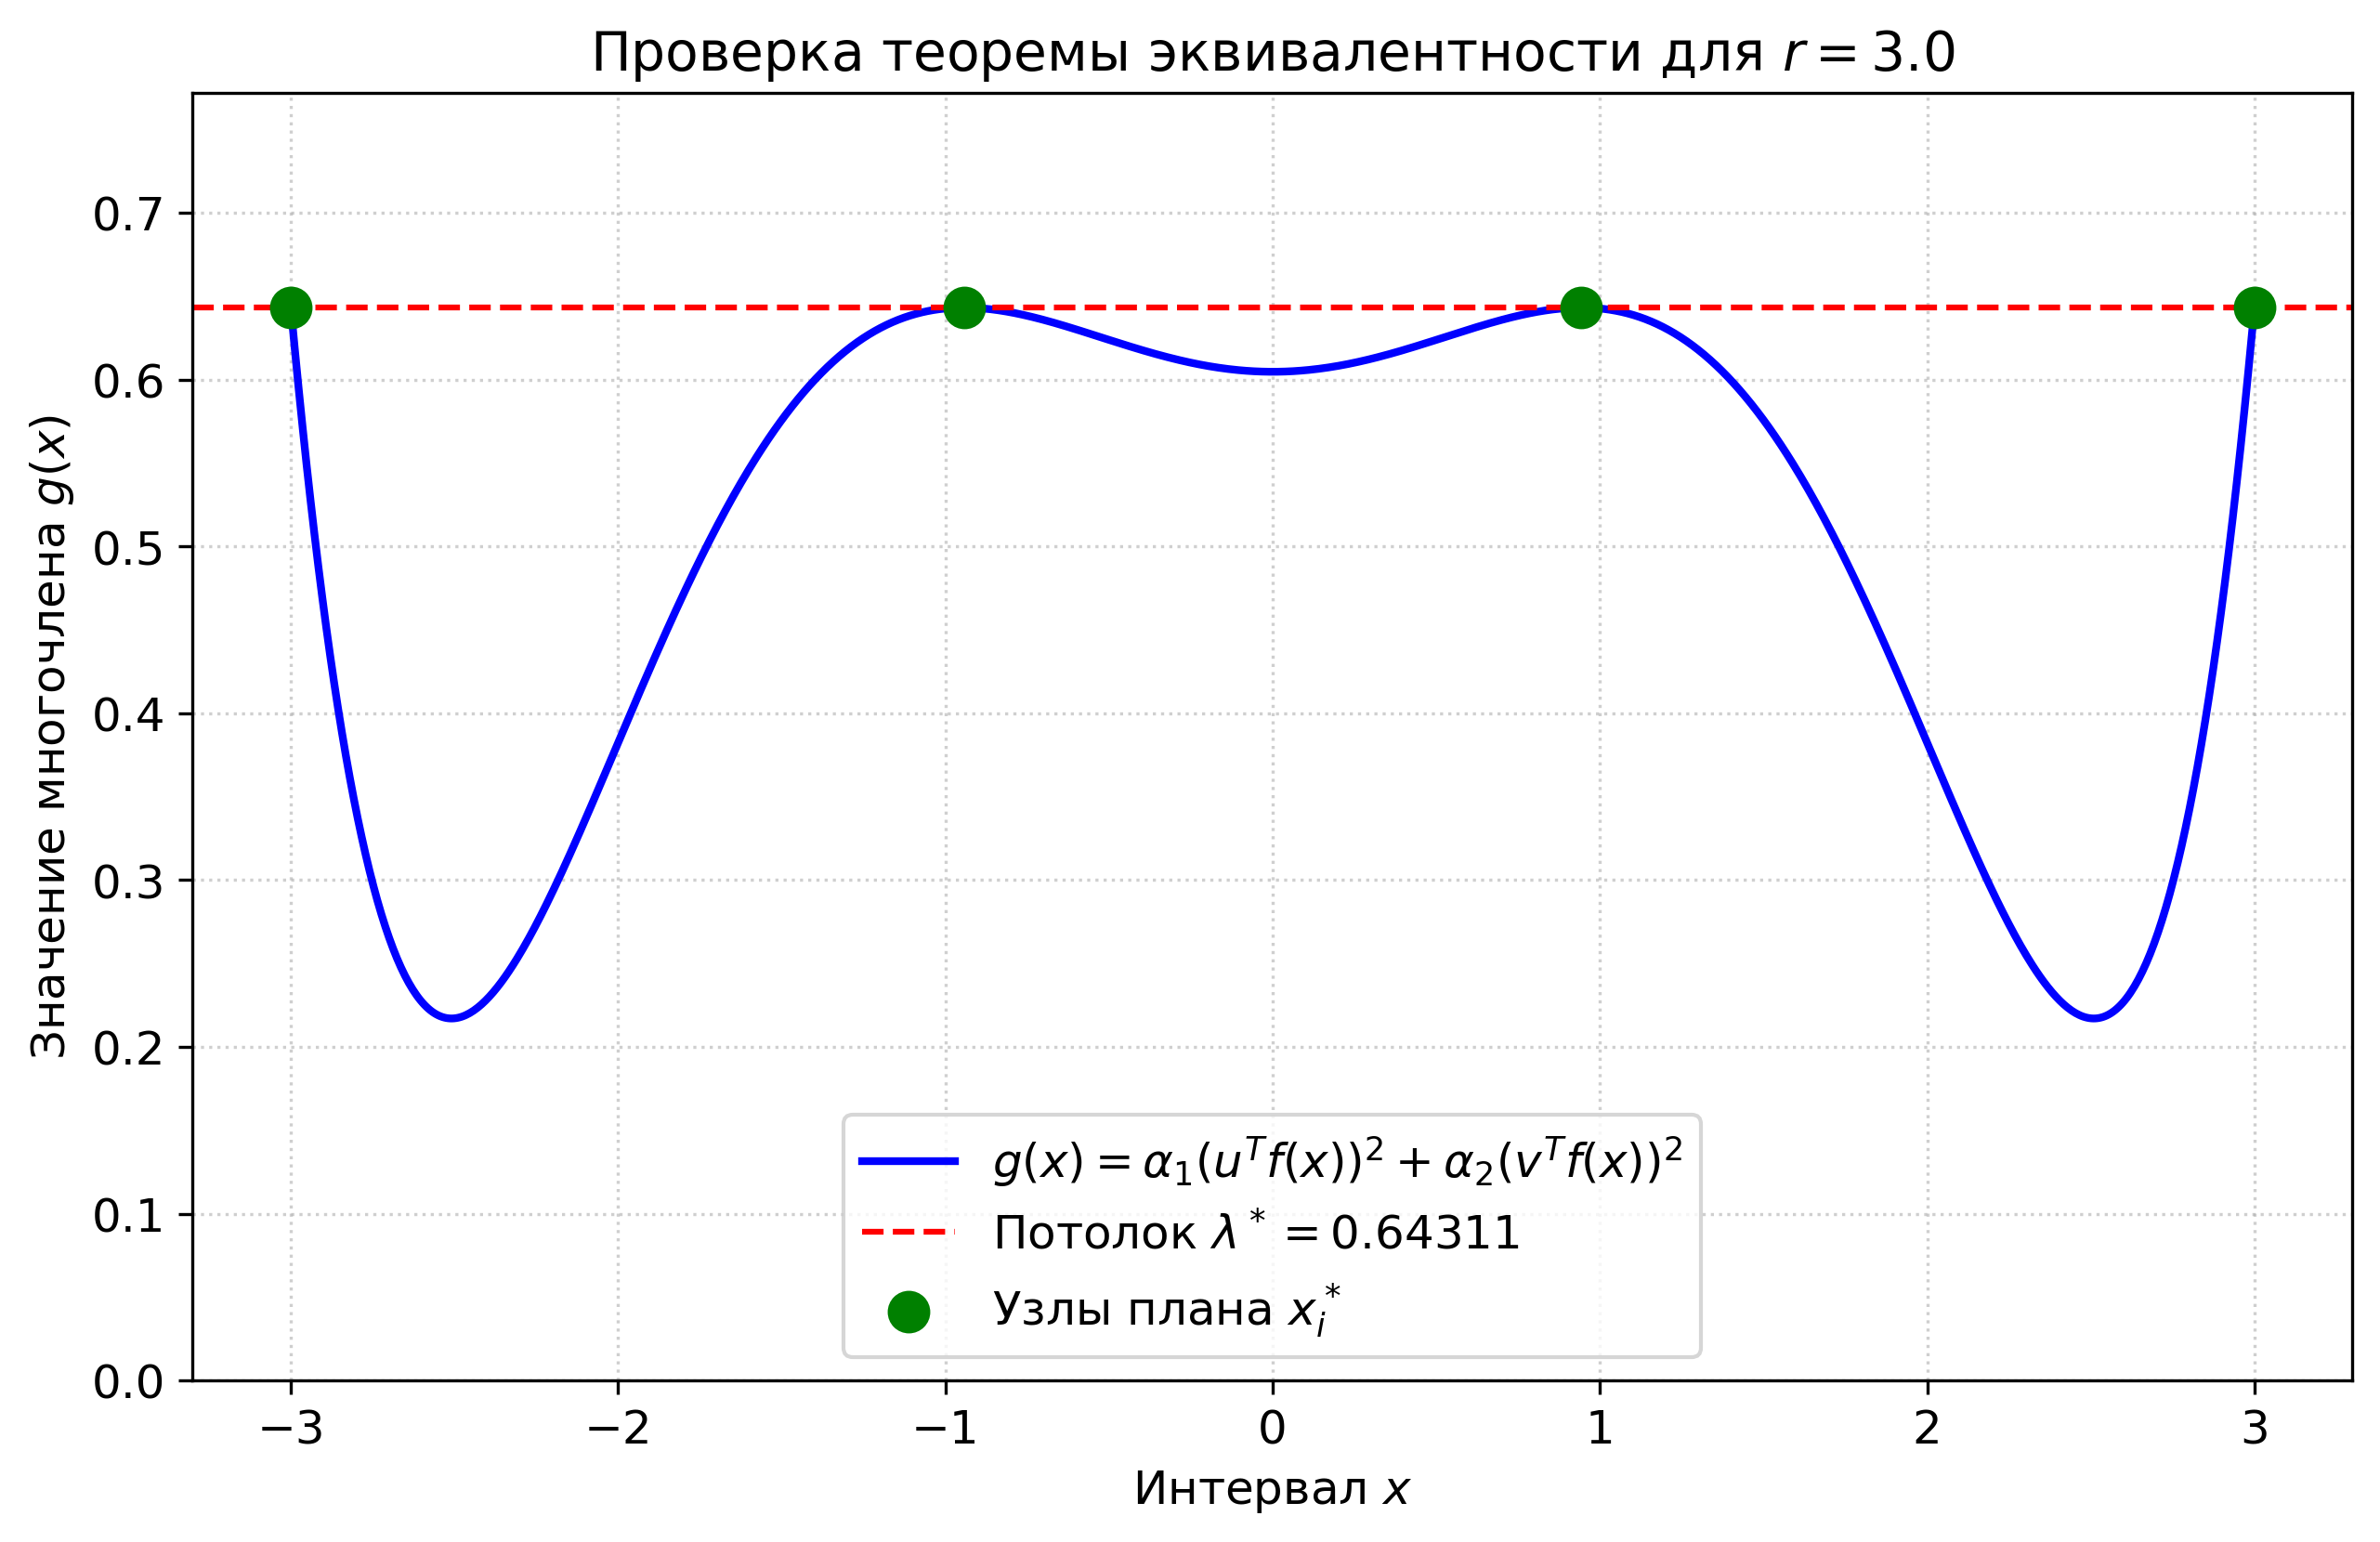

In [168]:
if __name__ == "__main__":
    # Запустите для критического отрезка r=3.0
    plot_equivalence_theorem_symmetric(3.0)

In [169]:
if __name__ == "__main__":
    # Параметры из Главы 3
    r_val = 3.0
    omega_val = 1

    print("\n" + "="*60)
    print("ГЕНЕРАЦИЯ ДАННЫХ ДЛЯ ТАБЛИЦЫ В ГЛАВЕ 3")
    print("="*60)

    # 1. Аналитический метод (SymPy) - линейное приближение
    p_an, w_an, l_an = solve_shifted_design_analytical(r_val, omega_val)

    # 2. Численный метод (SLSQP) - точный эталон
    # Границы отрезка: [-r + omega, r + omega]
    p_num, w_num, l_num = solve_numerical_arbitrary(-r_val + omega_val, r_val + omega_val)
    
    print("--- Внутренние узлы (x2*, x3*) ---")
    print(f"Аналитический метод: x2 = {p_an[1]:.5f}, x3 = {p_an[2]:.5f}")
    print(f"Численный эталон   : x2 = {p_num[1]:.5f}, x3 = {p_num[2]:.5f}")

    print("\n--- Веса узлов (mu1, mu2, mu3, mu4) ---")
    print(f"Аналитический метод: {w_an[0]:.5f} | {w_an[1]:.5f} | {w_an[2]:.5f} | {w_an[3]:.5f}")
    print(f"Численный эталон   : {w_num[0]:.5f} | {w_num[1]:.5f} | {w_num[2]:.5f} | {w_num[3]:.5f}")


ГЕНЕРАЦИЯ ДАННЫХ ДЛЯ ТАБЛИЦЫ В ГЛАВЕ 3
--- Внутренние узлы (x2*, x3*) ---
Аналитический метод: x2 = 0.05658, x3 = 1.94342
Численный эталон   : x2 = -0.26921, x3 = 1.89943

--- Веса узлов (mu1, mu2, mu3, mu4) ---
Аналитический метод: 0.04394 | 0.45606 | 0.45606 | 0.04394
Численный эталон   : 0.08257 | 0.66479 | 0.21950 | 0.03314


In [170]:
# 13. Сравнительные численные эксперименты
if __name__ == "__main__":
    r_val = 3.0
    omega_val = 0.01 # Огромный сдвиг! Отрезок [-2.0, 4.0]

    print("Запуск шагового аналитического метода...")
    p_an, w_an, l_an = solve_shifted_design_stepwise(r_val, omega_val, steps=10)

    print("Запуск численного эталона (SLSQP)...")
    p_num, w_num, l_num = solve_numerical_arbitrary(-r_val + omega_val, r_val + omega_val)

    print("\n" + "="*60)
    print("СРАВНЕНИЕ АНАЛИТИЧЕСКОГО ШАГОВОГО МЕТОДА И ЧИСЛЕННОГО РЕШЕНИЯ")
    print(f"Отрезок: [{-r_val + omega_val}, {r_val + omega_val}]")
    print("="*60)
    print(f"Аналитические точки: {np.round(p_an, 5)}")
    print(f"Численные точки:     {np.round(p_num, 5)}")
    print(f"\nАналитические веса : {np.round(w_an, 5)}")
    print(f"Численные веса :     {np.round(w_num, 5)}")

Запуск шагового аналитического метода...
Запуск численного эталона (SLSQP)...

СРАВНЕНИЕ АНАЛИТИЧЕСКОГО ШАГОВОГО МЕТОДА И ЧИСЛЕННОГО РЕШЕНИЯ
Отрезок: [-2.99, 3.01]
Аналитические точки: [-2.99    -2.98989  3.00992  3.01   ]
Численные точки:     [-2.99    -0.93579  0.9514   3.01   ]

Аналитические веса : [-3463.99477  3464.5052   4815.71118 -4815.22161]
Численные веса :     [0.04424 0.45861 0.45324 0.04391]


In [171]:
# 13. Сравнительные численные эксперименты
if __name__ == "__main__":
    r_val = 3.0
    omega_val = 0.5 # ОГРОМНЫЙ СДВИГ!
    h=0.1

    print(f"Запуск ШАГОВОГО аналитического метода ({round(omega_val/h)} шагов)...")
    p_an, w_an, l_an = solve_shifted_design_stepwise(r_val, omega_val, steps=round(omega_val/h))

    print("Запуск численного эталона (SLSQP)...")
    p_num, w_num, l_num = solve_numerical_arbitrary(-r_val + omega_val, r_val + omega_val)

    print("\n" + "="*60)
    print(f"СРАВНЕНИЕ ДЛЯ ОГРОМНОГО СДВИГА (Отрезок [{-r_val + omega_val}, {r_val + omega_val}])")
    print("="*60)
    print(f"Аналитические точки: {np.round(p_an, 5)}")
    print(f"Численные точки:     {np.round(p_num, 5)}")
    print(f"\nАналитические веса : {np.round(w_an, 5)}")
    print(f"Численные веса :     {np.round(w_num, 5)}")

Запуск ШАГОВОГО аналитического метода (5 шагов)...
Запуск численного эталона (SLSQP)...

СРАВНЕНИЕ ДЛЯ ОГРОМНОГО СДВИГА (Отрезок [-2.5, 3.5])
Аналитические точки: [-2.5     -2.4999   3.49995  3.5    ]
Численные точки:     [-2.5     -0.58071  1.3815   3.5    ]

Аналитические веса : [-5173.63008  5174.37675  4014.65498 -4014.40165]
Численные веса :     [0.05642 0.58128 0.32482 0.03748]


In [172]:
def compare_and_print(r_val: float, omega_val: float):
    """
    Автоматически рассчитывает аналитический и численный планы, 
    находит их реальные собственные числа из матриц Фишера, 
    вычисляет дельту и выводит красивую таблицу для Главы 3.
    """
    # 1. Расчет планов
    p_an, w_an, _ = solve_shifted_design_analytical(r_val, omega_val)
    p_num, w_num, _ = solve_numerical_arbitrary(-r_val + omega_val, r_val + omega_val)
    
    # 2. Вычисление фактических собственных чисел из матриц Фишера
    M_an = build_information_matrix(p_an, w_an)
    l_an_real = get_min_eigenvalue(M_an)
    
    M_num = build_information_matrix(p_num, w_num)
    l_num_real = get_min_eigenvalue(M_num)
    
    # 3. Расчет абсолютных разностей (Дельта)
    delta_p = np.abs(p_an - p_num)
    delta_w = np.abs(w_an - w_num)
    delta_l = np.abs(l_an_real - l_num_real)
    
    # 4. Форматированный вывод таблицы в консоль
    print("\n" + "="*78)
    print(f"СРАВНИТЕЛЬНЫЙ АНАЛИЗ ПЛАНОВ ДЛЯ ГЛАВЫ 3 (r = {r_val}, omega = {omega_val})")
    print("="*78)
    print(f"│ {'Параметр плана':<25} │ {'Аналитический':^15} │ {'Численный':^12} │ {'Разность (Delta)':^16} │")
    print("├" + "─"*27 + "┼" + "─"*17 + "┼" + "─"*14 + "┼" + "─"*20 + "┤")
    
    # Вывод узлов x
    for i in range(4):
        node_name = f"Узел x{i+1}" + (" (граница)" if i in [0, 3] else " (внутр.)")
        print(f"│ {node_name:<25} │ {p_an[i]:^15.5f} │ {p_num[i]:^12.5f} │ {delta_p[i]:^20.5f} │")
        
    print("├" + "─"*27 + "┼" + "─"*17 + "┼" + "─"*14 + "┼" + "─"*20 + "┤")
    
    # Вывод весов mu
    for i in range(4):
        weight_name = f"Вес mu{i+1}"
        print(f"│ {weight_name:<25} │ {w_an[i]:^15.5f} │ {w_num[i]:^12.5f} │ {delta_w[i]:^20.5f} │")
        
    print("├" + "─"*27 + "┼" + "─"*17 + "┼" + "─"*14 + "┼" + "─"*20 + "┤")
    
    # Вывод критерия lambda_min
    print(f"│ {'Критерий lambda_min':<25} │ {l_an_real:^15.5f} │ {l_num_real:^12.5f} │ {delta_l:^20.5f} │")
    print("└" + "─"*27 + "┴" + "─"*17 + "┴" + "─"*14 + "┴" + "─"*20 + "┘")



In [173]:
def compare_and_print(r_val: float, omega_val: float):
    """
    Рассчитывает аналитический и численный планы, находит их реальные 
    собственные числа, вычисляет дельту и относительное отклонение в % 
    для построения расширенной таблицы в Главе 3.
    """
    # 1. Расчет планов
    p_an, w_an, _ = solve_shifted_design_analytical(r_val, omega_val)
    p_num, w_num, _ = solve_numerical_arbitrary(-r_val + omega_val, r_val + omega_val)
    
    # 2. Вычисление фактических собственных чисел из матриц Фишера
    M_an = build_information_matrix(p_an, w_an)
    l_an_real = get_min_eigenvalue(M_an)
    
    M_num = build_information_matrix(p_num, w_num)
    l_num_real = get_min_eigenvalue(M_num)
    
    # 3. Расчет абсолютных разностей (Дельта)
    delta_p = np.abs(p_an - p_num)
    delta_w = np.abs(w_an - w_num)
    delta_l = np.abs(l_an_real - l_num_real)
    
    # 4. Расчет относительного отклонения в процентах
    pct_p = np.zeros(4)
    for i in range(4):
        if p_num[i] != 0:
            pct_p[i] = (delta_p[i] / np.abs(p_num[i])) * 100.0
            
    pct_w = np.zeros(4)
    for i in range(4):
        if w_num[i] != 0:
            pct_w[i] = (delta_w[i] / np.abs(w_num[i])) * 100.0
            
    pct_l = (delta_l / np.abs(l_num_real)) * 100.0
    
    # 5. Форматированный вывод расширенной таблицы в консоль
    print("\n" + "="*95)
    print(f"СРАВНИТЕЛЬНЫЙ АНАЛИЗ ПЛАНОВ ДЛЯ ГЛАВЫ 3 (r = {r_val}, omega = {omega_val})")
    print("="*95)
    print(f"│ {'Параметр плана':<25} │ {'Аналитический':^15} │ {'Численный':^12} │ {'Разность (Delta)':^16} │ {'Отклонение (%)':^14} │")
    print("├" + "─"*27 + "┼" + "─"*17 + "┼" + "─"*14 + "┼" + "─"*20 + "┼" + "─"*16 + "┤")
    
    # Вывод узлов x
    for i in range(4):
        node_name = f"Узел x{i+1}" + (" (граница)" if i in [0, 3] else " (внутр.)")
        print(f"│ {node_name:<25} │ {p_an[i]:^15.5f} │ {p_num[i]:^12.5f} │ {delta_p[i]:^20.5f} │ {pct_p[i]:^14.2f}% │")
        
    print("├" + "─"*27 + "┼" + "─"*17 + "┼" + "─"*14 + "┼" + "─"*20 + "┼" + "─"*16 + "┤")
    
    # Вывод весов mu
    for i in range(4):
        weight_name = f"Вес mu{i+1}"
        print(f"│ {weight_name:<25} │ {w_an[i]:^15.5f} │ {w_num[i]:^12.5f} │ {delta_w[i]:^20.5f} │ {pct_w[i]:^14.2f}% │")
        
    print("├" + "─"*27 + "┼" + "─"*17 + "┼" + "─"*14 + "┼" + "─"*20 + "┼" + "─"*16 + "┤")
    
    # Вывод критерия lambda_min
    print(f"│ {'Критерий lambda_min':<25} │ {l_an_real:^15.5f} │ {l_num_real:^12.5f} │ {delta_l:^20.5f} │ {pct_l:^14.2f}% │")
    print("└" + "─"*27 + "┴" + "─"*17 + "┴" + "─"*14 + "┴" + "─"*20 + "┴" + "─"*16 + "┘")

In [174]:

if __name__ == "__main__":
    # Параметры вычислительного эксперимента из Главы 3
    r_val = 3.0
    omega_val = 0.01

    # Запуск автоматического расчета и вывода таблицы
    compare_and_print(r_val, omega_val)
    
    # Запуск построения графика оптимальности g(x)
    # plot_equivalence_theorem_symmetric(3.0)


СРАВНИТЕЛЬНЫЙ АНАЛИЗ ПЛАНОВ ДЛЯ ГЛАВЫ 3 (r = 3.0, omega = 0.01)
│ Параметр плана            │  Аналитический  │  Численный   │ Разность (Delta) │ Отклонение (%) │
├───────────────────────────┼─────────────────┼──────────────┼────────────────────┼────────────────┤
│ Узел x1 (граница)         │    -2.99000     │   -2.99000   │       0.00000        │      0.00     % │
│ Узел x2 (внутр.)          │    -0.93342     │   -0.93579   │       0.00238        │      0.25     % │
│ Узел x3 (внутр.)          │     0.95342     │   0.95140    │       0.00202        │      0.21     % │
│ Узел x4 (граница)         │     3.01000     │   3.01000    │       0.00000        │      0.00     % │
├───────────────────────────┼─────────────────┼──────────────┼────────────────────┼────────────────┤
│ Вес mu1                   │     0.04394     │   0.04424    │       0.00031        │      0.69     % │
│ Вес mu2                   │     0.45606     │   0.45861    │       0.00254        │      0.55     % │
│ Вес mu3 

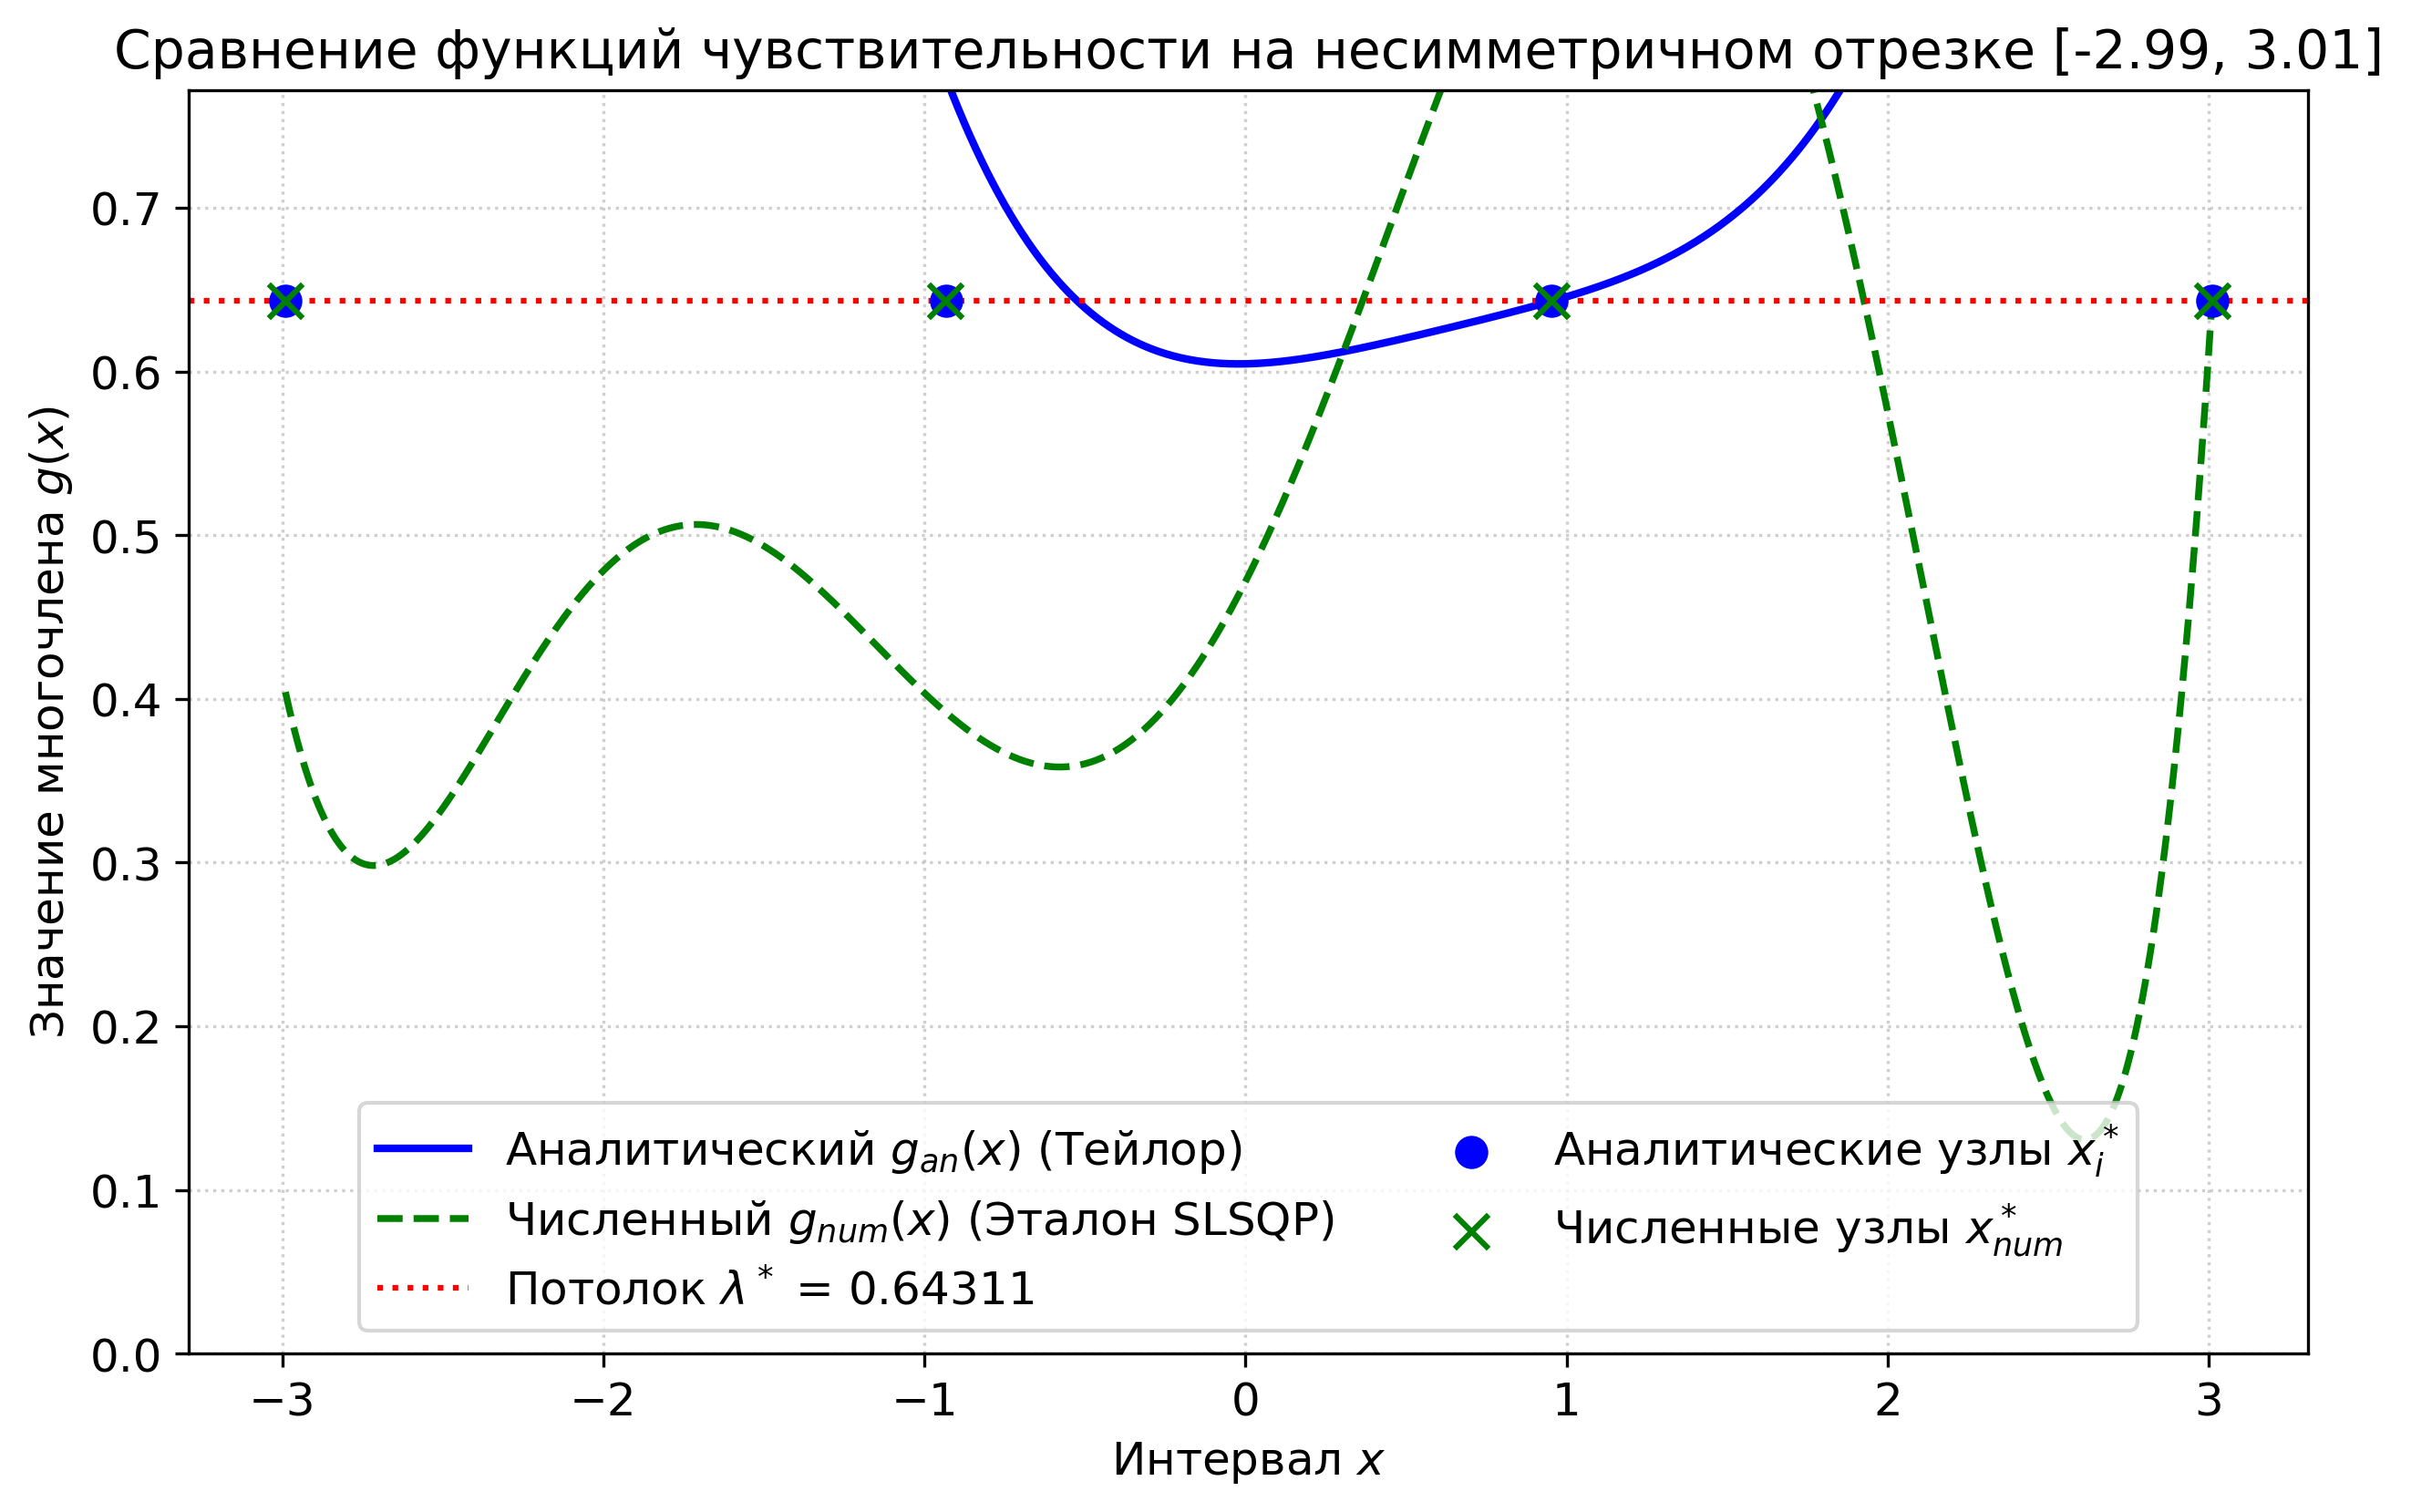

In [175]:
def plot_equivalence_theorem_comparison(r_val: float, omega_val: float):
    """
    Строит и сравнивает графики g(x) для аналитического сдвига 
    и численного эталона строго на интервале [-r+omega, r+omega].
    """
    theta_0_numeric = get_symmetric_theta_0_vector(r_val)
    
    omega = sp.Symbol('omega', real=True)
    p0, p1, p2 = sp.symbols('p0 p1 p2', real=True)
    q0, q1, q3 = sp.symbols('q0 q1 q3', real=True)
    mu2, mu3, mu4 = sp.symbols('mu2 mu3 mu4', real=True)
    x2, x3 = sp.symbols('x2 x3', real=True)
    theta_vars = [p0, p1, p2, q0, q1, q3, mu2, mu3, mu4, x2, x3]
    
    x1_norm, x4_norm = -1.0, 1.0
    mu1 = 1.0 - mu2 - mu3 - mu4
    p3, q2 = 0.0, 0.0
    X_pts = [x1_norm * r_val + omega, x2 * r_val + omega, x3 * r_val + omega, x4_norm * r_val + omega]
    Weights = [mu1, mu2, mu3, mu4]
    x_sym = sp.Symbol('x', real=True)
    p_x = p0 + p1*x_sym + p2*x_sym**2
    q_x = q0 + q1*x_sym + q2*x_sym**2 + q3*x_sym**3
    g_x = p_x**2 + q_x**2
    dg_dx = sp.diff(g_x, x_sym)
    lam = g_x.subs(x_sym, X_pts[3])
    
    p_coeffs = [p0, p1, p2, p3]
    q_coeffs = [q0, q1, q2, q3]
    
    equations = []
    equations.append(g_x.subs(x_sym, X_pts[0]) - lam)
    equations.append(g_x.subs(x_sym, X_pts[1]) - lam)
    equations.append(g_x.subs(x_sym, X_pts[2]) - lam)
    equations.append(dg_dx.subs(x_sym, X_pts[1]))
    equations.append(dg_dx.subs(x_sym, X_pts[2]))
    for k in range(4):
        moment_p = sum(Weights[i] * p_x.subs(x_sym, X_pts[i]) * (X_pts[i]**k) for i in range(4))
        equations.append(moment_p - lam * p_coeffs[k])
    for k in range(2):
        moment_q = sum(Weights[i] * q_x.subs(x_sym, X_pts[i]) * (X_pts[i]**k) for i in range(4))
        equations.append(moment_q - lam * q_coeffs[k])
        
    F = sp.Matrix(equations)
    G_sym = F.jacobian(theta_vars)
    G_omega_sym = -F.diff(omega)
    
    subs_list = [(omega, 0.0)]
    for i in range(11):
        subs_list.append((theta_vars[i], float(theta_0_numeric[i])))
        
    G_0_num = np.array(G_sym.subs(subs_list), dtype=np.float64)
    G_omega_0_num = np.array(G_omega_sym.subs(subs_list), dtype=np.float64).flatten()
    
    active_indices = [1, 3, 5]
    G_reduced = G_0_num[:, active_indices]
    theta_active_dot, _, _, _ = np.linalg.lstsq(G_reduced, G_omega_0_num, rcond=None)
    
    theta_1_numeric = np.zeros(11)
    for i, idx in enumerate(active_indices):
        theta_1_numeric[idx] = theta_active_dot[i]
        
    theta_final = np.array(theta_0_numeric) + theta_1_numeric * omega_val
    
    p0_an, p1_an, p2_an = theta_final[0], theta_final[1], theta_final[2]
    q0_an, q1_an, q3_an = theta_final[3], theta_final[4], theta_final[5]
    
    # Численный эталон (SLSQP)
    r1, r2 = -r_val + omega_val, r_val + omega_val
    p_num, w_num, lam_num = solve_numerical_arbitrary(r1, r2)
    
    M_num = build_information_matrix(p_num, w_num)
    evals, evecs = np.linalg.eigh(M_num)
    
    u_num = evecs[:, 0]
    v_num = evecs[:, 1]
    
    f_r2 = np.array([1, r2, r2**2, r2**3])
    U_num = np.dot(u_num, f_r2)
    V_num = np.dot(v_num, f_r2)
    
    alpha_1 = (lam_num - V_num**2) / (U_num**2 - V_num**2)
    alpha_2 = 1.0 - alpha_1
    
    # Сетка на реальном сдвинутом отрезке [r1, r2]
    x_grid = np.linspace(r1, r2, 1000)
    g_an_vals = np.zeros_like(x_grid)
    g_num_vals = np.zeros_like(x_grid)
    
    for i, x_val in enumerate(x_grid):
        p_an_x = p0_an + p1_an*x_val + p2_an*x_val**2
        q_an_x = q0_an + q1_an*x_val + q3_an*x_val**2
        g_an_vals[i] = p_an_x**2 + q_an_x**2
        
        f_x = np.array([1, x_val, x_val**2, x_val**3])
        g_num_vals[i] = alpha_1 * (np.dot(u_num, f_x))**2 + alpha_2 * (np.dot(v_num, f_x))**2
        
    plt.rcParams.update({'font.size': 12, 'figure.dpi': 300})
    plt.figure(figsize=(10, 6))
    
    plt.plot(x_grid, g_an_vals, 'b-', label='Аналитический $g_{an}(x)$ (Тейлор)', linewidth=2)
    plt.plot(x_grid, g_num_vals, 'g--', label='Численный $g_{num}(x)$ (Эталон SLSQP)', linewidth=1.8)
    plt.axhline(y=lam_num, color='r', linestyle=':', label=f'Потолок $\\lambda^*$ = {lam_num:.5f}')
    
    # Физические точки
    p_an_phys = np.array([-r_val, theta_final[9] * r_val, theta_final[10] * r_val, r_val]) + omega_val
    plt.scatter(p_an_phys, [lam_num]*4, color='blue', s=60, zorder=5, label='Аналитические узлы $x_i^*$')
    plt.scatter(p_num, [lam_num]*4, color='green', marker='x', s=80, zorder=5, label='Численные узлы $x_{num}^*$')
    
    plt.title(f'Сравнение функций чувствительности на несимметричном отрезке [{r1:.2f}, {r2:.2f}]')
    plt.xlabel('Интервал $x$')
    plt.ylabel('Значение многочлена $g(x)$')
    plt.ylim(0, lam_num * 1.2)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower center', ncol=2)
    
    plt.savefig('equivalence_comparison.png', bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    # Запускаем строго на вашем отрезке [-2.99, 3.01] (r=3.0, omega=0.01)
    plot_equivalence_theorem_comparison(3.0, 0.01)

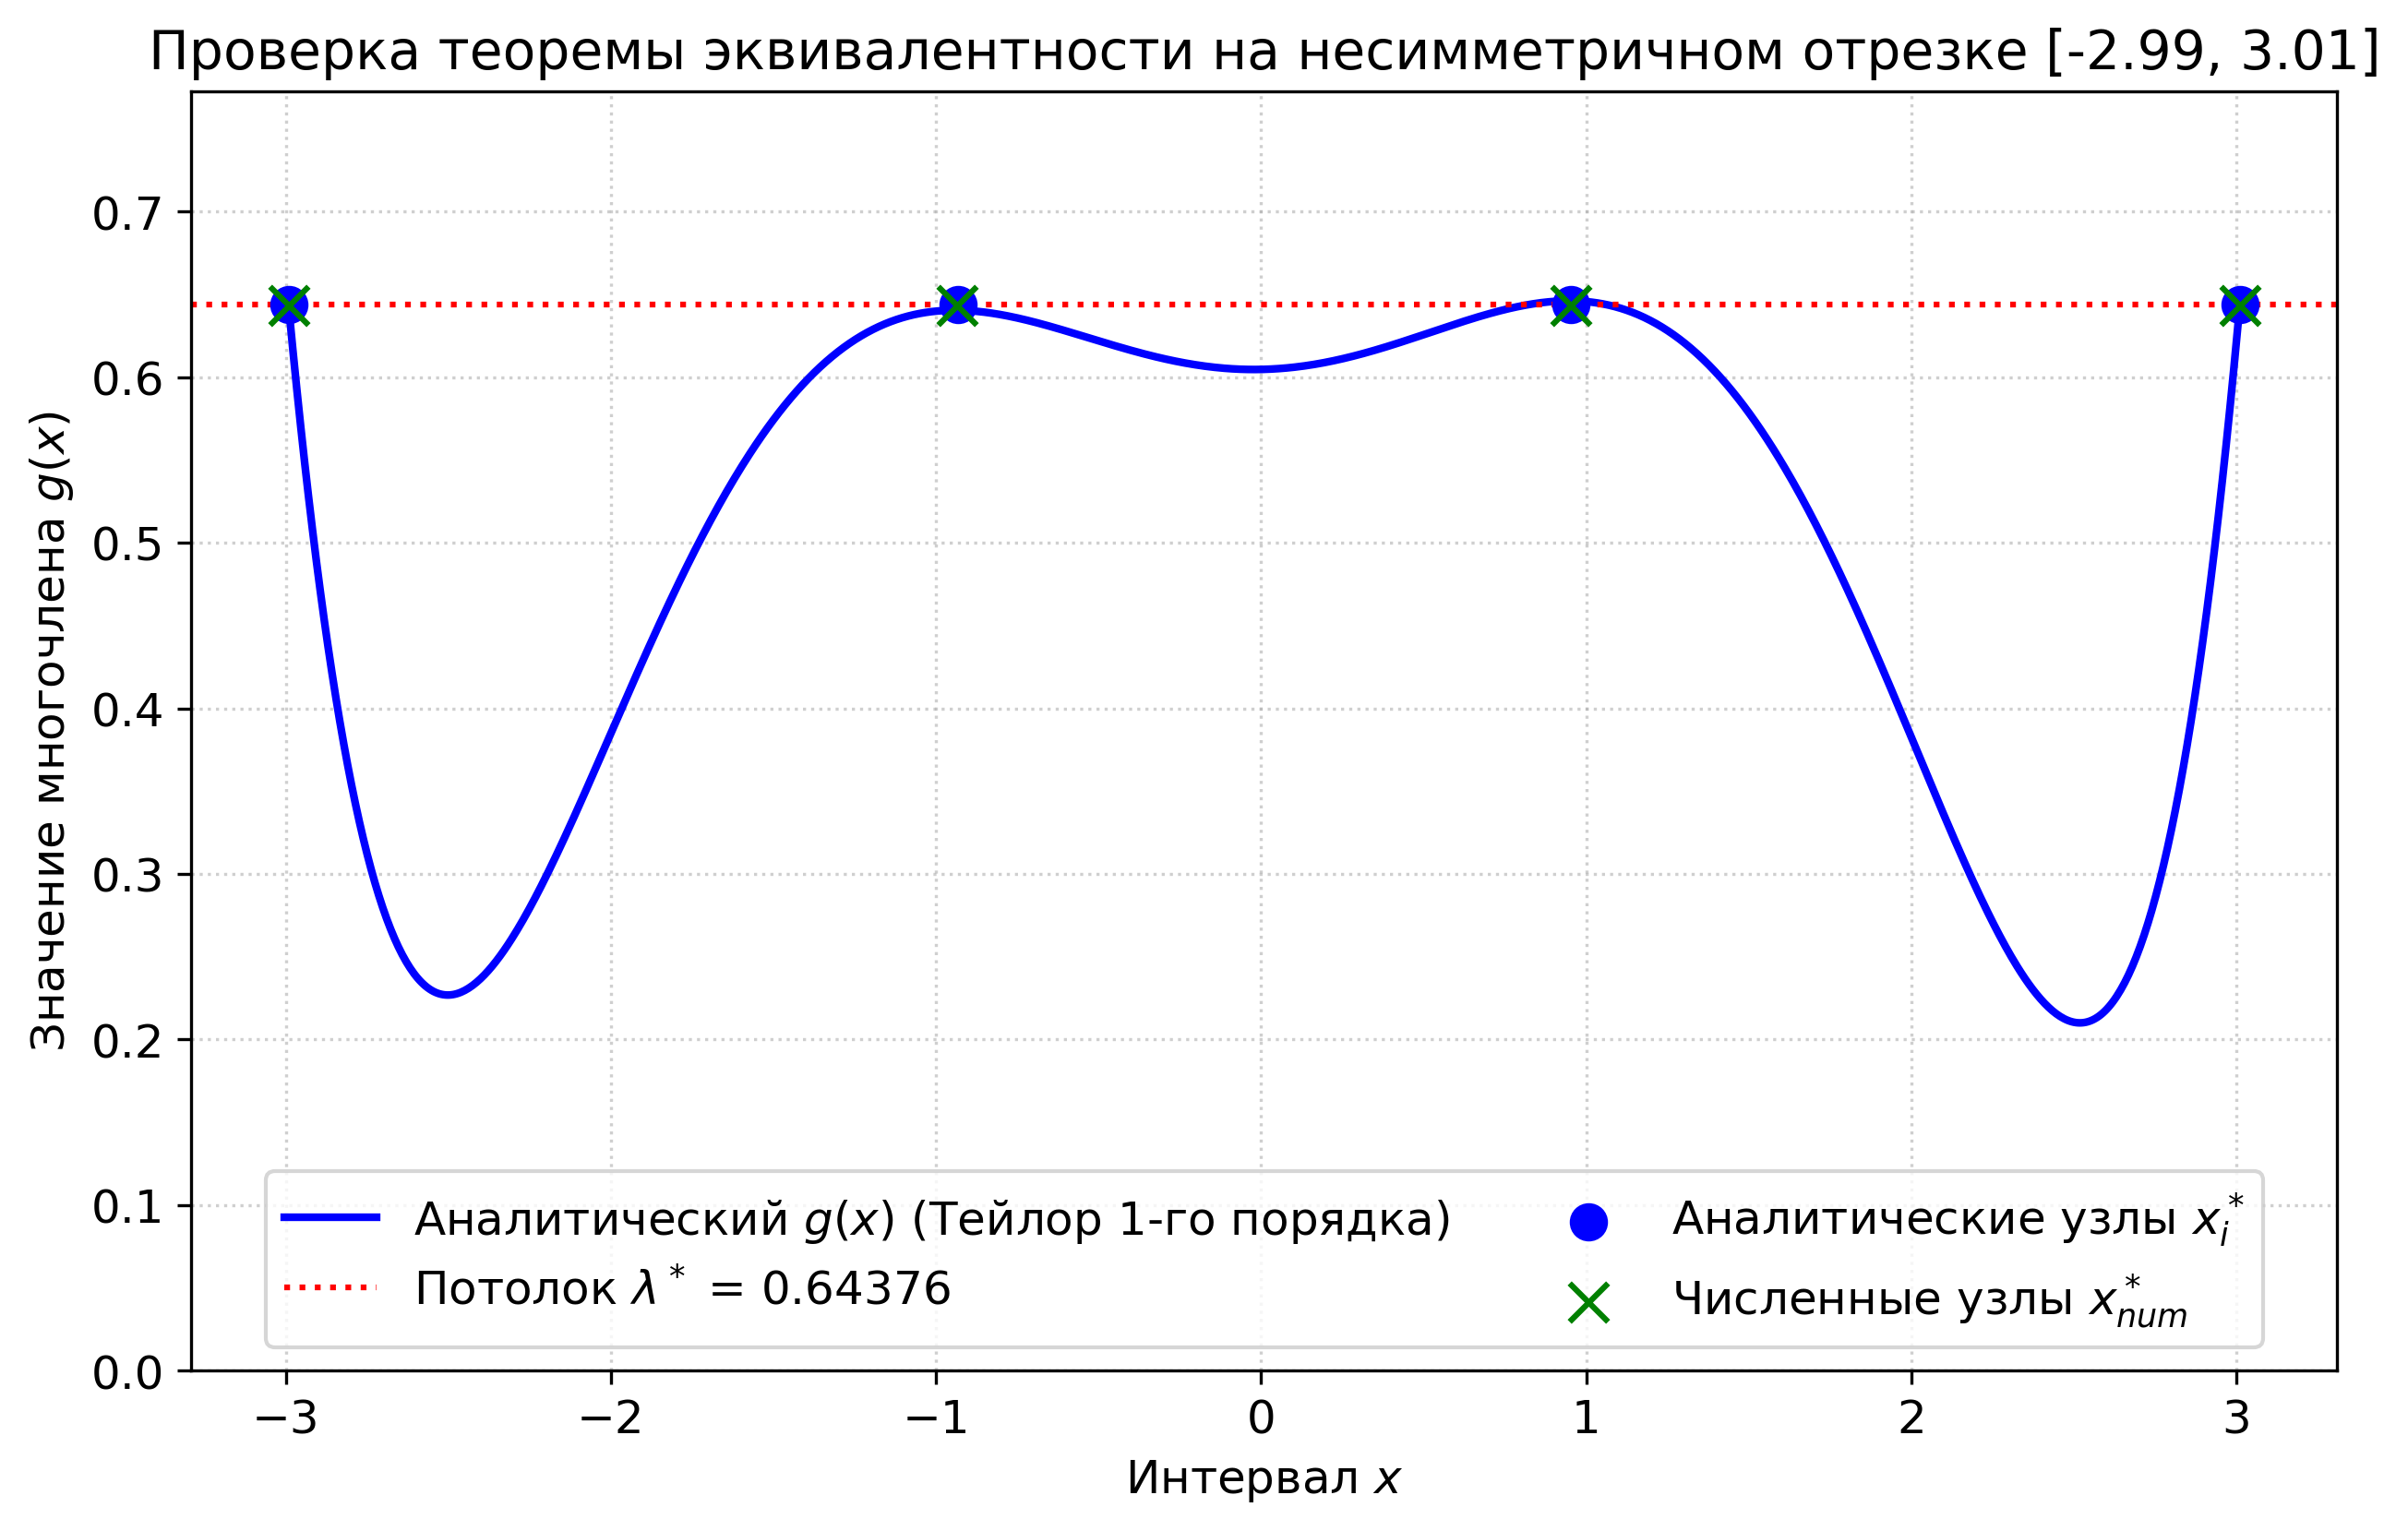

In [177]:
def plot_equivalence_theorem_comparison(r_val: float, omega_val: float):
    """
    Строит график функции чувствительности g(x) для аналитического сдвига (1-й порядок)
    и проверяет касание в узлах аналитического и численного планов.
    """
    # 1. Получаем аналитические параметры через сдвиг
    theta_0_numeric = get_symmetric_theta_0_vector(r_val)
    
    omega = sp.Symbol('omega', real=True)
    p0, p1, p2 = sp.symbols('p0 p1 p2', real=True)
    q0, q1, q3 = sp.symbols('q0 q1 q3', real=True)
    mu2, mu3, mu4 = sp.symbols('mu2 mu3 mu4', real=True)
    x2, x3 = sp.symbols('x2 x3', real=True)
    theta_vars = [p0, p1, p2, q0, q1, q3, mu2, mu3, mu4, x2, x3]
    
    x1_norm, x4_norm = -1.0, 1.0
    mu1 = 1.0 - mu2 - mu3 - mu4
    p3, q2 = 0.0, 0.0
    X_pts = [x1_norm * r_val + omega, x2 * r_val + omega, x3 * r_val + omega, x4_norm * r_val + omega]
    Weights = [mu1, mu2, mu3, mu4]
    
    x_sym = sp.Symbol('x', real=True)
    p_x = p0 + p1*x_sym + p2*x_sym**2
    q_x = q0 + q1*x_sym + q2*x_sym**2 + q3*x_sym**3
    g_x = p_x**2 + q_x**2
    dg_dx = sp.diff(g_x, x_sym)
    lam = g_x.subs(x_sym, X_pts[3])
    
    p_coeffs = [p0, p1, p2, p3]
    q_coeffs = [q0, q1, q2, q3]
    
    equations = []
    equations.append(g_x.subs(x_sym, X_pts[0]) - lam)
    equations.append(g_x.subs(x_sym, X_pts[1]) - lam)
    equations.append(g_x.subs(x_sym, X_pts[2]) - lam)
    equations.append(dg_dx.subs(x_sym, X_pts[1]))
    equations.append(dg_dx.subs(x_sym, X_pts[2]))
    for k in range(4):
        moment_p = sum(Weights[i] * p_x.subs(x_sym, X_pts[i]) * (X_pts[i]**k) for i in range(4))
        equations.append(moment_p - lam * p_coeffs[k])
    for k in range(2):
        moment_q = sum(Weights[i] * q_x.subs(x_sym, X_pts[i]) * (X_pts[i]**k) for i in range(4))
        equations.append(moment_q - lam * q_coeffs[k])
        
    F = sp.Matrix(equations)
    G_sym = F.jacobian(theta_vars)
    G_omega_sym = -F.diff(omega)
    
    subs_list = [(omega, 0.0)]
    for i in range(11):
        subs_list.append((theta_vars[i], float(theta_0_numeric[i])))
        
    G_0_num = np.array(G_sym.subs(subs_list), dtype=np.float64)
    G_omega_0_num = np.array(G_omega_sym.subs(subs_list), dtype=np.float64).flatten()
    
    active_indices = [1, 3, 5]
    G_reduced = G_0_num[:, active_indices]
    theta_active_dot, _, _, _ = np.linalg.lstsq(G_reduced, G_omega_0_num, rcond=None)
    
    theta_1_numeric = np.zeros(11)
    for i, idx in enumerate(active_indices):
        theta_1_numeric[idx] = theta_active_dot[i]
        
    theta_final = np.array(theta_0_numeric) + theta_1_numeric * omega_val
    
    # Распаковка коэффициентов многочленов
    p0_an, p1_an, p2_an = theta_final[0], theta_final[1], theta_final[2]
    q0_an, q1_an, q3_an = theta_final[3], theta_final[4], theta_final[5]
    
    # Физические точки аналитического плана
    x2_norm_val, x3_norm_val = theta_final[9], theta_final[10]
    p_an = np.array([-r_val, x2_norm_val * r_val, x3_norm_val * r_val, r_val]) + omega_val
    
    # Расчет целевой линии (потолка) по формуле
    subs_list_final = [(omega, omega_val)]
    for i in range(11):
        subs_list_final.append((theta_vars[i], float(theta_final[i])))
    lam_an = float(lam.subs(subs_list_final))
    
    # 2. Получаем численный эталон (SLSQP)
    r1, r2 = -r_val + omega_val, r_val + omega_val
    p_num, w_num, lam_num = solve_numerical_arbitrary(r1, r2)
    
    # 3. Строим сетку на реальном сдвинутом отрезке [r1, r2]
    x_grid = np.linspace(r1, r2, 1000)
    g_an_vals = np.zeros_like(x_grid)
    
    for i, x_val in enumerate(x_grid):
        p_an_x = p0_an + p1_an*x_val + p2_an*x_val**2
        # ИСПРАВЛЕНА КРИТИЧЕСКАЯ ОПЕЧАТКА: x_val**3
        q_an_x = q0_an + q1_an*x_val + q3_an*x_val**3 
        g_an_vals[i] = p_an_x**2 + q_an_x**2
        
    # 4. Визуализация
    plt.rcParams.update({'font.size': 12, 'figure.dpi': 300})
    plt.figure(figsize=(10, 6))
    
    plt.plot(x_grid, g_an_vals, 'b-', label='Аналитический $g(x)$ (Тейлор 1-го порядка)', linewidth=2)
    plt.axhline(y=lam_an, color='r', linestyle=':', label=f'Потолок $\\lambda^*$ = {lam_an:.5f}')
    
    # Отмечаем точки планов
    plt.scatter(p_an, [lam_an]*4, color='blue', s=80, zorder=5, label='Аналитические узлы $x_i^*$')
    plt.scatter(p_num, [lam_num]*4, color='green', marker='x', s=100, zorder=6, label='Численные узлы $x_{num}^*$')
    
    plt.title(f'Проверка теоремы эквивалентности на несимметричном отрезке [{r1:.2f}, {r2:.2f}]')
    plt.xlabel('Интервал $x$')
    plt.ylabel('Значение многочлена $g(x)$')
    
    # Масштабируем ось Y для красивого отображения
    plt.ylim(0, lam_an * 1.2)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower center', ncol=2)
    
    plt.savefig('equivalence_comparison.png', bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_equivalence_theorem_comparison(3.0, 0.01)